# Task 1 – Data Profiling & Data Quality

**Goal:** get an overview of the data quality of `leads.csv` and `conversions.csv` (row counts, missing values,
duplicates, suspicious values, value ranges) and derive a list of concrete data-quality (DQ) issues, each with
a criticality and a proposed handling. The notebook is the basis for the dbt pipeline: section 11 turns the
findings into staging rules and tests.

**How this notebook works: a discovery loop.** Nothing is assumed up front. Each section *looks* at the data,
states a **Finding** and, where needed, applies a **Fix** to a working copy. Every following section then builds
on cleaner data. The raw frames are never modified.

**Toy data, big-data habits.** The files are tiny (123 + 51 rows), but the code is written as if they were not:
vectorised string operations instead of row-wise Python, expensive steps only on *distinct* values, aggregation
before plotting, samples instead of full dumps. The fixes here are exploratory. The production cleaning belongs
in the staging layer (Tasks 2 and 4).

In [1]:
import warnings

import numpy as np
import pandas as pd
import plotly.express as px
from pandas.tseries.api import guess_datetime_format

# Shared by the notebooks, see notebooks/common/
from common import RAW_DATA_DIR, configure_plotly

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
configure_plotly()

## 1. Load the raw files

Everything is read **as text** (`dtype=str`), and empty fields stay empty strings (`keep_default_na=False`).
Nothing is converted or guessed at read time, so the notebook sees exactly what is in the files.

In [2]:
leads_raw = pd.read_csv(RAW_DATA_DIR / "leads.csv", dtype=str, keep_default_na=False)
conv_raw = pd.read_csv(RAW_DATA_DIR / "conversions.csv", dtype=str, keep_default_na=False)

pd.DataFrame(
    {
        "rows": [len(leads_raw), len(conv_raw)],
        "columns": [leads_raw.shape[1], conv_raw.shape[1]],
    },
    index=["leads", "conversions"],
)

,rows,columns
leads,123,6
conversions,51,6


In [3]:
leads_raw.head()

,lead_id,email,vertical,source,created_at,region
0,1087,Sophia.wagner@aon.at,haushalt,direct,05/02/2024,
1,1056,lea.brunner@outlook.com,haushalt,newsletter,2024-04-22,Kaernten
2,1071,michael.fischer@gmx.at,auto,google,25.09.2024,Vorarlberg
3,1095,emma.leitner@outlook.com,haushalt,google,2024-10-30,Kaernten
4,1032,clara.moser@gmail.com,leben,direct,06.10.2024,Salzburg


In [4]:
conv_raw.head()

,conversion_id,lead_id,email,premium,signed_date,status
0,5036,1103,sophie.gruber@gmx.at,422.42,15.03.2024,active
1,5021,1047,julia.brunner@hotmail.com,"1299,57",04.03.2024,active
2,5001,1076,julia.pichler@hotmail.com,"431,77",30.04.2024,active
3,5030,1111,ELIAS.WINKLER@OUTLOOK.COM,"212,26",08/12/2024,cancelled
4,5041,1007,anna.wagner@gmx.at,218.22,02.07.2024,cancelled


## 2. What formats do the values have?

Instead of writing a regex for every format we *expect*, each value is reduced to its **shape**: digits become
`9`, runs of capitals become `A`, runs of lower-case letters become `a`, and spaces become `␣`. For example,
`2024-04-22` becomes `9999-99-99` and `  Lea.Weber@gmx.at` becomes `␣␣Aa.a@a.a`.

Counting the shapes per column reveals format variants without knowing in advance what to look for. It is one
vectorised pass per column, and the number of distinct shapes stays small even for millions of rows.

In [5]:
def shape(s: pd.Series) -> pd.Series:
    """Reduce every value to its format: digits -> 9, letter runs -> A / a, spaces -> ␣."""
    return (
        s.str.replace(r"\d", "9", regex=True)
        .str.replace(r"[A-Z]+", "A", regex=True)
        .str.replace(r"[a-z]+", "a", regex=True)
        .str.replace(" ", "␣", regex=False)
        .replace("", "(empty)")
    )


def shape_profile(df: pd.DataFrame, table: str) -> pd.DataFrame:
    """One row per (column, shape) with the number of rows and one example value."""
    values = df.melt(var_name="column", value_name="value")
    values["shape"] = shape(values["value"])
    return (
        values.groupby(["column", "shape"], as_index=False)
        .agg(rows=("value", "size"), example=("value", "first"))
        .assign(table=table)
    )


shapes = pd.concat([shape_profile(leads_raw, "leads"), shape_profile(conv_raw, "conversions")])

# Columns with a single shape are consistent. Only the ones that mix shapes are shown.
n_shapes = shapes.groupby(["table", "column"])["shape"].transform("nunique")
(
    shapes[n_shapes > 1]
    .sort_values(["table", "column", "rows"], ascending=[False, True, False])
    .set_index(["table", "column", "shape"])
)

rows                       example
table       column      shape                                         
leads       created_at  9999-99-99    61                    2024-04-22
                        99.99.9999    36                    25.09.2024
                        99/99/9999    26                    05/02/2024
            email       a.a@a.a       86       lea.brunner@outlook.com
                        A.A@A.A       15         NOAH.GRUBER@GMAIL.COM
                        ␣␣a.a@a.a     13    thomas.mueller@outlook.com
                        Aa.a@a.a       5          Sophia.wagner@aon.at
                        a.a@a.a␣       4           lukas.mayer@aon.at 
            region      Aa           118                      Kaernten
                        (empty)        5                              
            vertical    a            120                      haushalt
                        (empty)        3                              
conversions email       a.a@a.a       38     julia.pichler@hotmail.com
                        A.A@A.A        7     ELIAS.WINKLER@OUTLOOK.COM
                        ␣␣a.a@a.a      6          sophie.gruber@gmx.at
            lead_id     9999          42                          1103
                        99999          6                         99874
                        (empty)        3                              
            premium     999.99        29                        422.42
                        999,99        10                        431,77
                        9999.99        5                       1359.55
                        9999,99        3                       1299,57
                        (empty)        2                              
                        -99.99         1                        -73.36
                        -999.99        1                       -217.61
            signed_date 9999-99-99    27                    2024-05-30
                        99.99.9999    16                    15.03.2024
                        99/99/9999     8                    08/12/2024
            status      a             50                        active
                        A              1                        ACTIVE

**Finding:** without writing a single expected pattern, the shapes already reveal most of the problems:

| column | what the shapes show |
|---|---|
| `created_at`, `signed_date` | three date formats: `9999-99-99`, `99.99.9999` and `99/99/9999` |
| `email` (both files) | leading and trailing spaces (`␣␣a.a@a.a`, `a.a@a.a␣`) and capitals (`A.A@A.A`, `Aa.a@a.a`) |
| `premium` | decimal point *and* decimal comma (`999.99` vs `999,99`), negative values (`-99.99`), empty values |
| `conversions.lead_id` | 4-digit *and* 5-digit ids (`99999`), plus empty values |
| `status` | one value in capitals (`A`) |
| `vertical`, `region` | empty values |

`lead_id` in the leads, `conversion_id` and `source` each have a single, clean shape.

## 3. Fix 1: whitespace, empty strings and id types

The shapes showed surrounding whitespace and empty strings. From here on the notebook works on **working copies**
in which all text is trimmed and empty strings are real missing values (`NaN`). The raw frames stay untouched
for reference.

The id columns only have digit shapes, so they are cast to a **nullable integer** (`Int64`) right away. A plain
integer column cannot hold missing values, and pandas would silently turn it into a float column
(`1087` becomes `1087.0`).

In [6]:
def trim_and_null(df: pd.DataFrame) -> pd.DataFrame:
    """Strip surrounding whitespace from every text column and turn empty strings into NaN."""
    df = df.copy()
    for col in df.select_dtypes(str):
        df[col] = df[col].str.strip()
    return df.replace("", np.nan)


leads = trim_and_null(leads_raw).astype({"lead_id": "Int64"})
conv = trim_and_null(conv_raw).astype({"conversion_id": "Int64", "lead_id": "Int64"})

pd.concat({"leads": leads.dtypes, "conversions": conv.dtypes}).rename("dtype").to_frame()

dtype
leads       lead_id        Int64
            email            str
            vertical         str
            source           str
            created_at       str
            region           str
conversions conversion_id  Int64
            lead_id        Int64
            email            str
            premium          str
            signed_date      str
            status           str

## 4. Missing values

With empty strings turned into `NaN`, missing values can be measured the same way for every column.

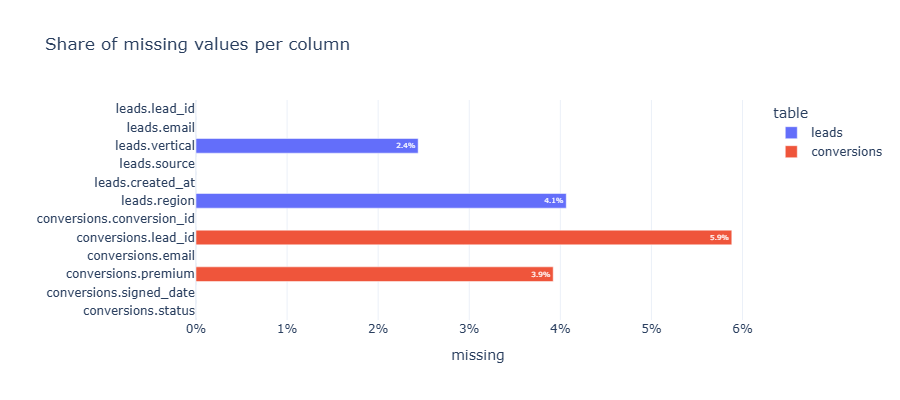

In [7]:
missing = (
    pd.concat({"leads": leads.isna().mean(), "conversions": conv.isna().mean()})
    .rename_axis(["table", "column"])
    .rename("missing_share")
    .reset_index()
)
missing["column"] = missing["table"] + "." + missing["column"]

fig = px.bar(
    missing,
    x="missing_share",
    y="column",
    color="table",
    orientation="h",
    text_auto=".1%",
    title="Share of missing values per column",
    labels={"missing_share": "missing", "column": ""},
)
fig.update_xaxes(tickformat=".0%")
fig.update_yaxes(autorange="reversed")
fig.show()

Are the gaps spread over many rows, or concentrated in a few broken rows?

In [8]:
# Rows with at least one missing field, by how many fields are missing
missing_per_row = pd.DataFrame(
    {
        "leads": leads.isna().sum(axis=1).value_counts(),
        "conversions": conv.isna().sum(axis=1).value_counts(),
    }
).drop(index=0, errors="ignore")
missing_per_row.index.name = "missing fields per row"
missing_per_row.fillna(0).astype(int)

,leads,conversions
missing fields per row,,
1,8,5


In [9]:
# A sample of the affected rows in each file
display(leads[leads.isna().any(axis=1)].head())
conv[conv.isna().any(axis=1)].head()

,lead_id,email,vertical,source,created_at,region
0,1087,Sophia.wagner@aon.at,haushalt,direct,05/02/2024,NaN
18,1075,SOPHIA.WEBER@AON.AT,NaN,newsletter,2024-05-12,Tirol
20,1021,florian.fuchs@aon.at,haushalt,google,03/10/2024,NaN
40,1045,tobias.gruber@hotmail.com,NaN,direct,10/11/2024,Vorarlberg
48,1010,emma.aigner@outlook.com,haushalt,google,20.10.2024,NaN


,conversion_id,lead_id,email,premium,signed_date,status
7,5048,<NA>,julia.mueller@gmail.com,1293.44,17.03.2024,pending
20,5050,<NA>,clara.winkler@gmx.at,1160.88,06/21/2024,pending
23,5024,1104,sophie.gruber@hotmail.com,NaN,01.07.2024,active
35,5049,<NA>,mia.berger@gmail.com,881.65,2024-03-11,cancelled
39,5033,1059,mia.gruber@gmail.com,NaN,08.02.2024,cancelled


**Finding:**
- leads: `vertical` is missing 3 times (2.4 %), `region` 5 times (4.1 %).
- conversions: `lead_id` is missing 3 times (5.9 %), so these conversions cannot be linked to a lead by id.
  `premium` is missing 2 times (3.9 %).
- No row misses more than one field, so these are gaps in single fields, not broken rows.

Missing `vertical` and `region` are candidates for an explicit `'unknown'` category instead of dropping rows.
Missing `premium` and `lead_id` are looked at in sections 8 and 9.

## 5. Value sets of the categorical columns

Which columns are categorical is decided by the data: every column with at most 20 distinct values. On a large
table this threshold still works, because the number of categories does not grow with the number of rows.

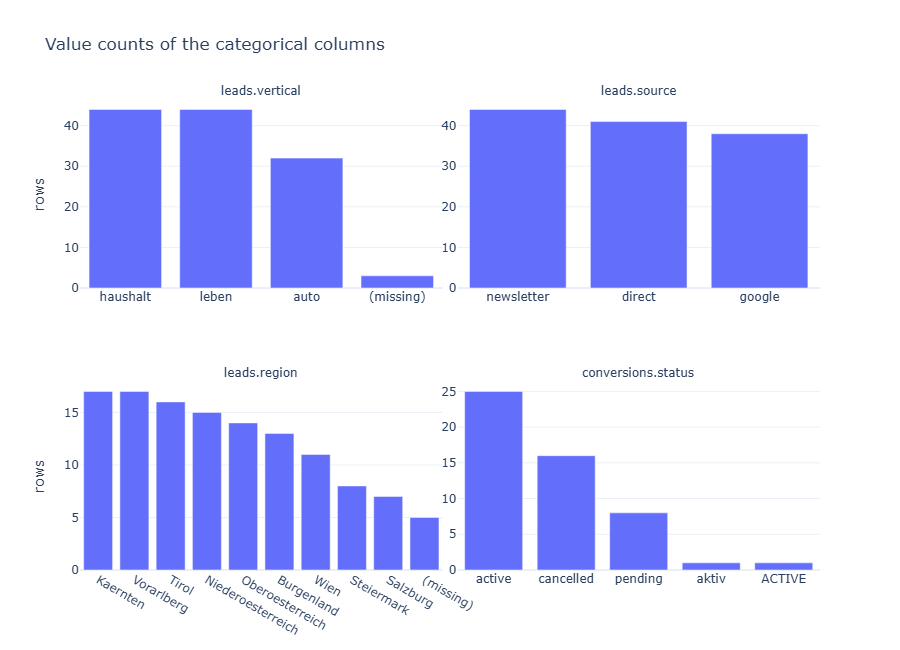

In [10]:
MAX_CATEGORIES = 20


def value_counts_long(df: pd.DataFrame, table: str) -> pd.DataFrame:
    """Value counts (missing values included) of all low-cardinality columns, in long format."""
    columns = [col for col in df.columns if df[col].nunique() <= MAX_CATEGORIES]
    counts = (
        df[columns]
        .fillna("(missing)")
        .melt(var_name="column", value_name="value")
        .value_counts()
        .rename("rows")
        .reset_index()
    )
    counts["column"] = table + "." + counts["column"]
    return counts


counts = pd.concat([value_counts_long(leads, "leads"), value_counts_long(conv, "conversions")])

fig = px.bar(
    counts,
    x="value",
    y="rows",
    facet_col="column",
    facet_col_wrap=2,
    facet_row_spacing=0.2,
    title="Value counts of the categorical columns",
    height=650,
)
fig.update_xaxes(matches=None, showticklabels=True, title=None)
fig.update_yaxes(matches=None, showticklabels=True)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

**Finding:**
- `vertical` (auto / haushalt / leben) and `source` (google / newsletter / direct) only contain the values
  documented in the assignment. `vertical` has 3 missing values.
- `status` has **5** values instead of the documented 3: `ACTIVE` (capitals) and `aktiv` (German spelling) appear
  next to `active`. Anything that counts active contracts would miss them.
- `region` contains the 9 Austrian federal states, written with `ae`/`oe` instead of umlauts, plus 5 missing values.

In a pipeline, the documented value sets become *accepted values* tests (Task 4), so that a new spelling fails
loudly instead of silently dropping out of a KPI.

### Case variants in e-mail addresses

The e-mail address is the only attribute that identifies a person across leads and conversions, so its
normalisation matters. How many *different* addresses are there after each cleaning step?

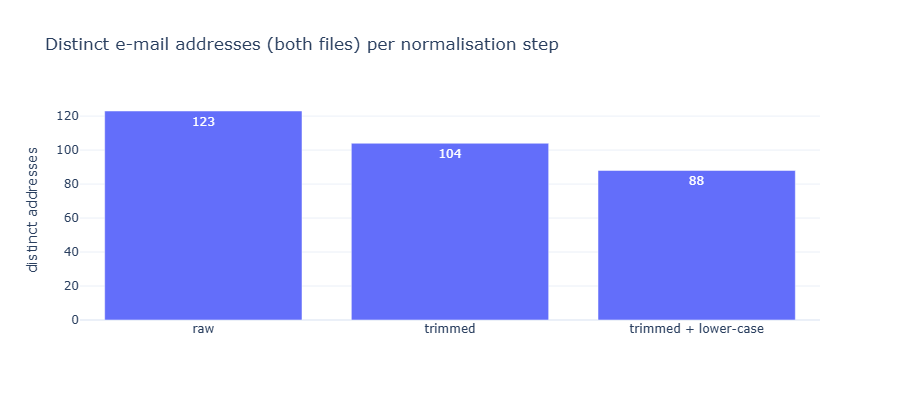

In [11]:
emails = pd.concat([leads_raw["email"], conv_raw["email"]])
email_steps = pd.DataFrame(
    {
        "step": ["raw", "trimmed", "trimmed + lower-case"],
        "distinct addresses": [
            emails.nunique(),
            emails.str.strip().nunique(),
            emails.str.strip().str.lower().nunique(),
        ],
    }
)

fig = px.bar(
    email_steps,
    x="step",
    y="distinct addresses",
    text_auto=True,
    title="Distinct e-mail addresses (both files) per normalisation step",
)
fig.update_xaxes(title=None)
fig.show()

**Finding:** across both files, 123 raw spellings shrink to 104 after trimming and to 88 distinct addresses
after lower-casing. E-mail addresses are case-insensitive in practice, so both steps are safe.

**Fix 2:** lower-case the e-mails; lower-case `status` and map the German spelling to the documented value.

In [12]:
leads["email"] = leads["email"].str.lower()
conv["email"] = conv["email"].str.lower()
conv["status"] = conv["status"].str.lower().replace({"aktiv": "active"})

conv["status"].value_counts()

status
active       27
cancelled    16
pending       8
Name: count, dtype: int64

## 6. Dates: discover the formats, then parse

### 6.1 What do the standard approaches do?

In [13]:
created = leads["created_at"]
naive = pd.to_datetime(created, errors="coerce")
mixed = pd.to_datetime(created, format="mixed")

pd.DataFrame(
    {
        "parsed": [naive.notna().sum(), mixed.notna().sum()],
        "failed (NaT)": [naive.isna().sum(), mixed.isna().sum()],
    },
    index=["to_datetime(errors='coerce')", "to_datetime(format='mixed')"],
)

,parsed,failed (NaT)
to_datetime(errors='coerce'),26,97
to_datetime(format='mixed'),123,0


- The default infers **one** format from the first value (`05/02/2024`, month/day/year) and applies it to all
  values: 97 of 123 dates fail.
- `format="mixed"` guesses a format *per value* and parses everything, without any error. But is the result
  right? Section 6.3 checks it.

### 6.2 Discover the formats

pandas has a built-in format guesser, `guess_datetime_format`. Running it twice per value, once month-first and
once day-first, shows whether a value is **ambiguous**: `03/05/2024` could be 5 March or 3 May, so it gets two
different guesses. The guesser only runs on the *distinct* date strings, so its cost depends on the number of
distinct dates, not on the number of rows.

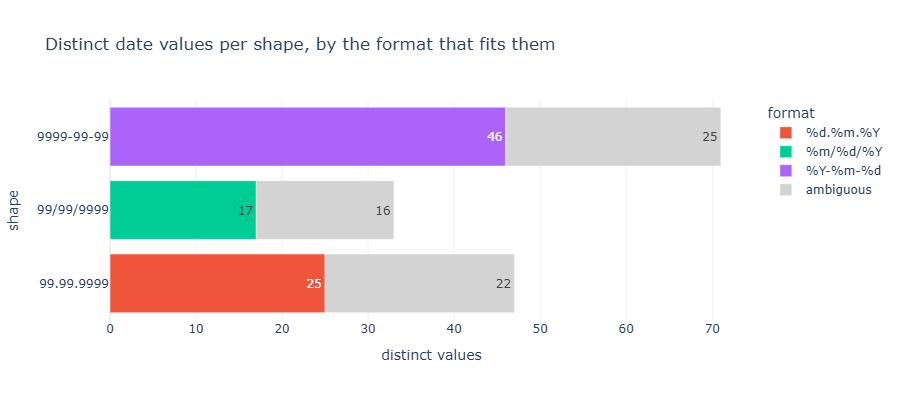

In [14]:
def guess_format(value: str, dayfirst: bool) -> str | None:
    """pandas' format guesser, without the warning it emits when dayfirst does not fit."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        return guess_datetime_format(value, dayfirst=dayfirst)


date_values = (
    pd.concat([leads["created_at"], conv["signed_date"]], ignore_index=True)
    .dropna()
    .drop_duplicates()
)
formats = pd.DataFrame(
    {
        "shape": shape(date_values),
        "month_first": date_values.map(lambda v: guess_format(v, dayfirst=False)),
        "day_first": date_values.map(lambda v: guess_format(v, dayfirst=True)),
    }
)
formats["format"] = np.select(
    [formats["month_first"].isna(), formats["month_first"] == formats["day_first"]],
    ["unknown", formats["month_first"]],
    default="ambiguous",
)

evidence = (
    formats.groupby(["shape", "format"])
    .size()
    .rename("distinct values")
    .reset_index()
    .sort_values("format", key=lambda s: s.eq("ambiguous"), kind="stable")  # ambiguous last
)

fig = px.bar(
    evidence,
    x="distinct values",
    y="shape",
    color="format",
    orientation="h",
    text_auto=True,
    color_discrete_map={"ambiguous": "lightgrey"},
    title="Distinct date values per shape, by the format that fits them",
)
fig.show()

Every bar has exactly one coloured segment next to the grey one: all unambiguous values of a shape fit the same
format. Grey values fit month-first and day-first alike. The guesser is strict: even ISO dates such as
`2024-05-12` count as ambiguous, because year-day-month would also be possible. So the convention of each shape is
taken from its unambiguous values:

In [15]:
format_per_shape = (
    formats[~formats["format"].isin(["ambiguous", "unknown"])]
    .groupby("shape")
    .agg(n_formats=("format", "nunique"), format=("format", "first"))
)
assert (format_per_shape["n_formats"] == 1).all(), "a shape mixes several formats"

format_per_shape = format_per_shape["format"]
format_per_shape

shape
99.99.9999    %d.%m.%Y
99/99/9999    %m/%d/%Y
9999-99-99    %Y-%m-%d
Name: format, dtype: str

**Finding:** there are three formats, one per shape, and no shape mixes conventions:
- `9999-99-99` is ISO (`%Y-%m-%d`),
- `99.99.9999` is day-first (`%d.%m.%Y`, the German format),
- `99/99/9999` is **month-first** (`%m/%d/%Y`, the US format): every unambiguous slash date has the month first,
  none has the day first.

The ambiguous values are parsed with the convention of their shape. That is an assumption; Task 2 cross-checks
it against the time between lead and contract.

### 6.3 Parse by shape and compare

In [16]:
def parse_dates(s: pd.Series, format_per_shape: pd.Series) -> pd.Series:
    """Parse each value with the format of its shape. Values of an unknown shape become NaT."""
    shapes = shape(s)
    parts = [
        pd.to_datetime(s[shapes == value_shape], format=fmt, errors="coerce")
        for value_shape, fmt in format_per_shape.items()
    ]
    return pd.concat(parts).reindex(s.index)


parsed = parse_dates(created, format_per_shape)
wrong = parsed != mixed

print(
    f"parse failures: {(created.notna() & parsed.isna()).sum()}, "
    f"dates that format='mixed' put on a different day: {wrong.sum()}"
)
pd.DataFrame({"text": created, "format='mixed'": mixed, "by shape": parsed})[wrong].head()

parse failures: 0, dates that format='mixed' put on a different day: 14


,text,format='mixed',by shape
4,06.10.2024,2024-06-10,2024-10-06
8,11.08.2024,2024-11-08,2024-08-11
12,01.08.2024,2024-01-08,2024-08-01
15,09.02.2024,2024-09-02,2024-02-09
29,08.05.2024,2024-08-05,2024-05-08


**Finding:** parsing by shape leaves no failures. `format="mixed"` did not raise an error either, but it put
14 of the 123 lead dates on the **wrong day**: it reads `06.10.2024` as 10 June instead of 6 October, while it reads
`25.09.2024` correctly, because it guesses every value on its own. A silent error like this is worse than a loud
one.

**Fix 3:** parse both date columns by shape.

In [17]:
for df, col in [(leads, "created_at"), (conv, "signed_date")]:
    text = df[col]
    df[col] = parse_dates(text, format_per_shape)
    print(
        f"{col}: {(text.notna() & df[col].isna()).sum()} parse failures, "
        f"from {df[col].min():%Y-%m-%d} to {df[col].max():%Y-%m-%d}"
    )

created_at: 0 parse failures, from 2024-01-05 to 2024-10-31
signed_date: 0 parse failures, from 2024-01-16 to 2024-11-29


### 6.4 Leads and conversions over time

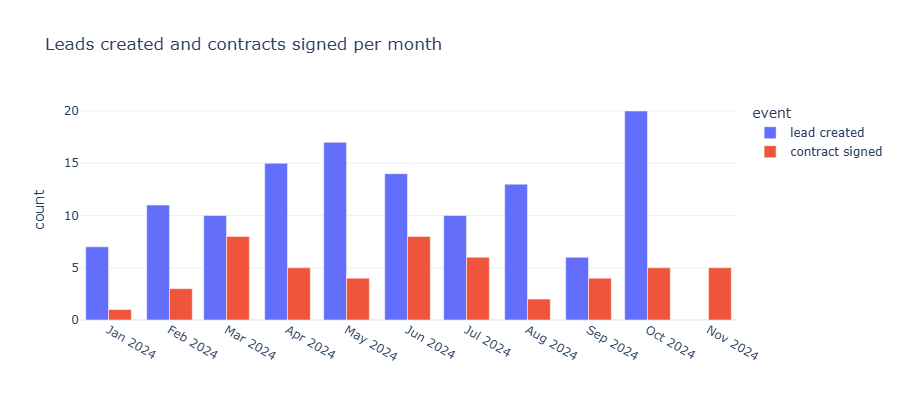

In [18]:
events = pd.concat(
    [
        pd.DataFrame({"date": leads["created_at"], "event": "lead created"}),
        pd.DataFrame({"date": conv["signed_date"], "event": "contract signed"}),
    ],
    ignore_index=True,
)

# Aggregate first, then plot: the figure only carries the monthly counts.
monthly = (
    events.assign(month=events["date"].dt.to_period("M").dt.start_time)
    .groupby(["month", "event"])
    .size()
    .rename("count")
    .reset_index()
)

fig = px.bar(
    monthly,
    x="month",
    y="count",
    color="event",
    barmode="group",
    category_orders={"event": ["lead created", "contract signed"]},
    title="Leads created and contracts signed per month",
)
fig.update_xaxes(dtick="M1", tickformat="%b %Y", title=None)
fig.show()

**Finding:** leads were created from 2024-01-05 to 2024-10-31, contracts signed from 2024-01-16 to 2024-11-29.
There are no leads after October, but conversions continue into November, because a contract is signed some time
after the lead. Leads from the last weeks have not had time to convert yet, so conversion rates for
the most recent months will look too low (right-censoring).

## 7. Duplicates

Three levels, on the cleaned data:
1. exact duplicate rows,
2. duplicate keys (`lead_id` / `conversion_id`), and in which columns the copies disagree,
3. the same person (e-mail) with several leads. This is not an error in itself, but it matters for the question
   "what is a customer" (Task 3).

In [19]:
for name, df, key in [("leads", leads, "lead_id"), ("conversions", conv, "conversion_id")]:
    exact = df.duplicated(keep=False)
    key_dup = df.duplicated(subset=[key], keep=False)
    print(
        f"{name}: exact duplicate rows = {df.duplicated().sum()} "
        f"(rows involved: {exact.sum()}), duplicate {key} values = {df[key][key_dup].nunique()}"
    )

leads: exact duplicate rows = 0 (rows involved: 0), duplicate lead_id values = 4
conversions: exact duplicate rows = 1 (rows involved: 2), duplicate conversion_id values = 1


In [20]:
dup_leads = leads[leads.duplicated("lead_id", keep=False)].sort_values("lead_id")
dup_leads.head(10)

,lead_id,email,vertical,source,created_at,region
55,1019,sophie.eder@gmail.com,haushalt,direct,2024-08-18,Niederoesterreich
86,1019,sophie.eder@gmail.com,haushalt,direct,2024-08-18,Wien
90,1030,sophie.aigner@hotmail.com,haushalt,newsletter,2024-01-24,Salzburg
115,1030,sophie.aigner@hotmail.com,haushalt,newsletter,2024-01-24,Tirol
18,1075,sophia.weber@aon.at,NaN,newsletter,2024-05-12,Tirol
75,1075,sophia.weber@aon.at,leben,google,2024-05-12,Burgenland
10,1117,noah.gruber@gmail.com,haushalt,newsletter,2024-08-19,Tirol
17,1117,noah.gruber@gmail.com,haushalt,google,2024-08-19,Wien


In how many of the duplicated leads does each column disagree between the copies?

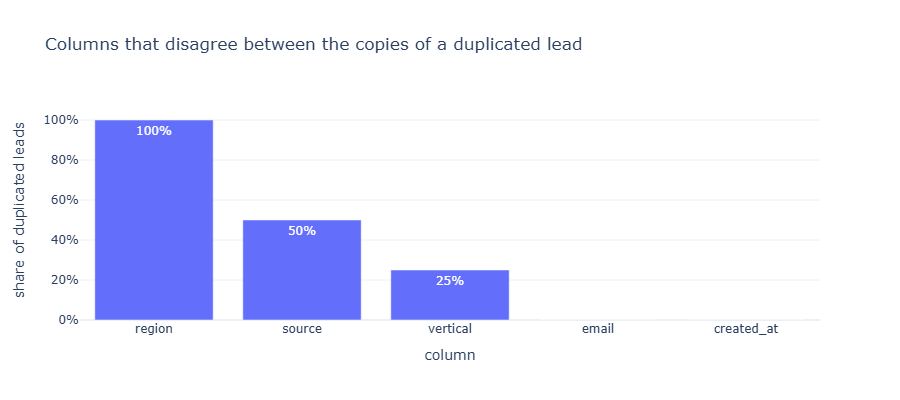

In [21]:
differs = (
    dup_leads.groupby("lead_id")
    .nunique(dropna=False)
    .gt(1)
    .mean()
    .sort_values(ascending=False)
    .rename("share of duplicated leads")
    .rename_axis("column")
    .reset_index()
)

fig = px.bar(
    differs,
    x="column",
    y="share of duplicated leads",
    text_auto=".0%",
    title="Columns that disagree between the copies of a duplicated lead",
)
fig.update_yaxes(tickformat=".0%", range=[0, 1.1])
fig.show()

**Finding:**
- **conversions:** one exact duplicate row (`conversion_id` 5020 appears twice). It would double-count a
  conversion and its premium.
- **leads:** no exact duplicates, but 4 `lead_id`s occur twice **with different content**. `region` differs in
  **every one** of them, `source` in half, `vertical` in one (a missing value vs `leben`). `email` and `created_at`
  never differ.

That pattern is interesting. If a lead had simply been submitted or exported twice, the copies would be identical.
A column that differs *every time* looks more like a **fan-out from an upstream join**: for example, region looked
up per session (geo-IP) or from an address table with several rows per person. If that is the case, `region` is
not a reliable attribute of a lead, and `source` might come from the same join. This is a question for the source
owner (see the open questions).

**Fix 4:** drop the exact duplicate conversion. Which copy of a duplicated lead wins is a modelling decision
(Task 2). The lookups below only need `email` and `created_at`, which are identical within each duplicate, so a
`leads_unique` frame with one row per `lead_id` is safe to use here.

In [22]:
conv = conv.drop_duplicates()
leads_unique = leads.drop_duplicates("lead_id")

print(f"conversions: {len(conv)} rows, leads_unique: {len(leads_unique)} rows")

conversions: 50 rows, leads_unique: 119 rows


### The same person with several leads

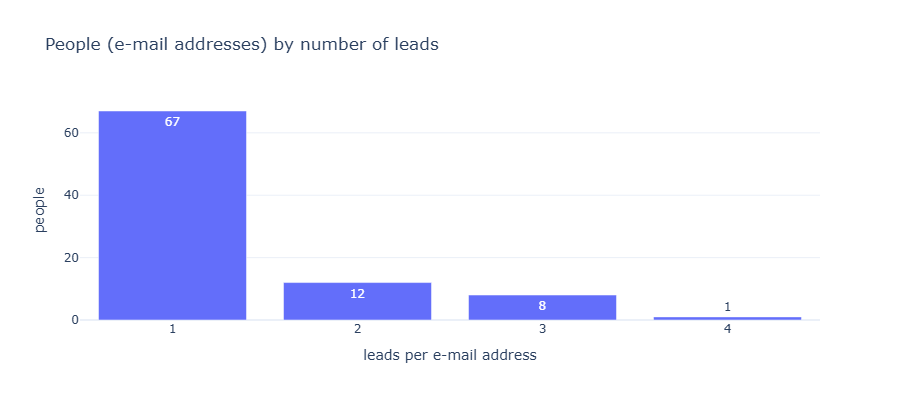

,n_leads,lead_ids
email,,
mia.berger@gmail.com,4,"[1016, 1017, 1069, 1070]"
florian.fuchs@aon.at,3,"[1020, 1021, 1022]"
noah.gruber@gmail.com,3,"[1115, 1116, 1117]"
emma.leitner@outlook.com,3,"[1093, 1094, 1095]"
laura.gruber@outlook.com,3,"[1023, 1024, 1025]"


In [23]:
leads_per_email = (
    leads_unique.sort_values("lead_id")
    .groupby("email")
    .agg(n_leads=("lead_id", "nunique"), lead_ids=("lead_id", list))
)
people = (
    leads_per_email["n_leads"]
    .value_counts()
    .sort_index()
    .rename("people")
    .reset_index()
)

fig = px.bar(
    people,
    x="n_leads",
    y="people",
    text_auto=True,
    title="People (e-mail addresses) by number of leads",
)
fig.update_xaxes(dtick=1, title="leads per e-mail address")
fig.show()

leads_per_email.sort_values("n_leads", ascending=False).head()

Are there names that appear with more than one e-mail domain?

In [24]:
email_parts = (
    leads_unique["email"]
    .str.split("@", expand=True)
    .set_axis(["local", "domain"], axis=1)
)
domains_per_name = email_parts.groupby("local")["domain"].transform("nunique")

(
    leads_unique.loc[domains_per_name > 1, ["lead_id", "email", "vertical", "created_at"]]
    .sort_values("email")
)

,lead_id,email,vertical,created_at
20,1021,florian.fuchs@aon.at,haushalt,2024-03-10
25,1020,florian.fuchs@aon.at,haushalt,2024-03-21
53,1022,florian.fuchs@aon.at,haushalt,2024-05-11
91,1037,florian.fuchs@gmx.at,leben,2024-08-18
106,1046,lena.hofer@gmail.com,haushalt,2024-05-10
63,1035,lena.hofer@outlook.com,auto,2024-07-17
8,1084,lukas.mayer@aon.at,leben,2024-08-11
100,1085,lukas.mayer@aon.at,haushalt,2024-04-20
118,1033,lukas.mayer@hotmail.com,leben,2024-06-22
76,1005,paul.aigner@gmail.com,leben,2024-08-24


**Finding:** after normalisation, 21 e-mail addresses have 2–4 leads each. That is expected behaviour (people use
several calculators) and not a DQ error, but it means that "lead" and "customer" are different grains. Five names
appear with two different e-mail domains, e.g. `paul.aigner@gmail.com` and `paul.aigner@hotmail.com`. They *could*
be the same person, but the data cannot prove it, so they are not merged.

## 8. Premium: parsing and value range

This section runs after the deduplication, so every contract is counted once. The shapes showed decimal
commas next to decimal points. What does a naive conversion do with them?

In [25]:
naive = pd.to_numeric(conv["premium"], errors="coerce")
lost = conv["premium"].notna() & naive.isna()

print(
    f"naive to_numeric: {lost.sum()} of {conv['premium'].notna().sum()} "
    f"non-missing premiums silently became NaN"
)
conv.loc[lost, ["conversion_id", "premium"]].head()

naive to_numeric: 13 of 48 non-missing premiums silently became NaN


,conversion_id,premium
1,5021,"1299,57"
2,5001,"431,77"
3,5030,"212,26"
8,5028,"1102,21"
11,5043,"894,41"


**Fix 5:** replace the decimal comma with a point before casting to a nullable float (`Float64`).

In [26]:
premium_text = conv["premium"]
conv["premium"] = pd.to_numeric(
    premium_text.str.replace(",", ".", regex=False),
    errors="coerce",
).astype("Float64")

failed = premium_text.notna() & conv["premium"].isna()
print(f"parse failures after replacing the decimal comma: {failed.sum()}")
conv["premium"].describe()

parse failures after replacing the decimal comma: 0


count          48.0
mean     606.344583
std      398.402362
min         -217.61
25%         264.445
50%          600.43
75%          884.84
max         1359.55
Name: premium, dtype: Float64

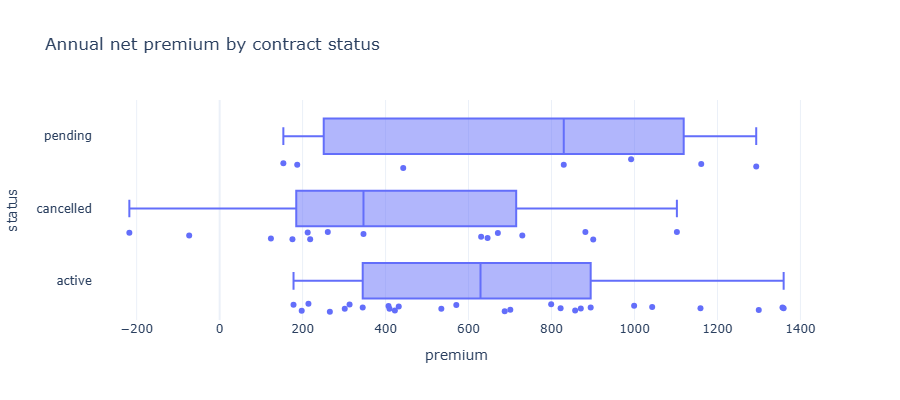

,conversion_id,lead_id,status
23,5024,1104,active
39,5033,1059,cancelled


In [27]:
fig = px.box(
    conv,
    x="premium",
    y="status",
    points="all",
    hover_data=["conversion_id"],
    title="Annual net premium by contract status",
)
fig.show()

conv.loc[conv["premium"].isna(), ["conversion_id", "lead_id", "status"]]

**Finding:**
- 13 of 48 premiums (27 %) use a decimal comma, and a naive conversion silently turns them into `NaN`. With the
  fix there are 0 parse failures. No thousands separators occur, so replacing the comma is safe.
- Values range from −217.61 to 1,359.55. The **two negative premiums** both belong to cancelled contracts. They
  could be refunds or reversal bookings, or errors (open question). There are no other outliers.
- 2 premiums are missing, one of them on an **active** contract, so the total active premium will be understated
  by one contract.

## 9. Do the conversions reference existing leads?

A conversion should point to its lead through `lead_id`. This is the first relationship a pipeline would test.

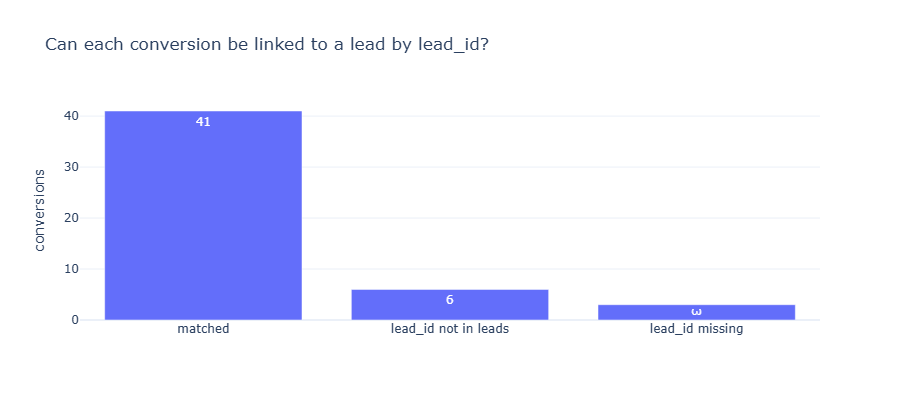

In [28]:
conv["link"] = np.select(
    [conv["lead_id"].isna(), conv["lead_id"].isin(leads_unique["lead_id"])],
    ["lead_id missing", "matched"],
    default="lead_id not in leads",
)

fig = px.bar(
    conv["link"].value_counts().rename("conversions").reset_index(),
    x="link",
    y="conversions",
    text_auto=True,
    title="Can each conversion be linked to a lead by lead_id?",
)
fig.update_xaxes(title=None)
fig.show()

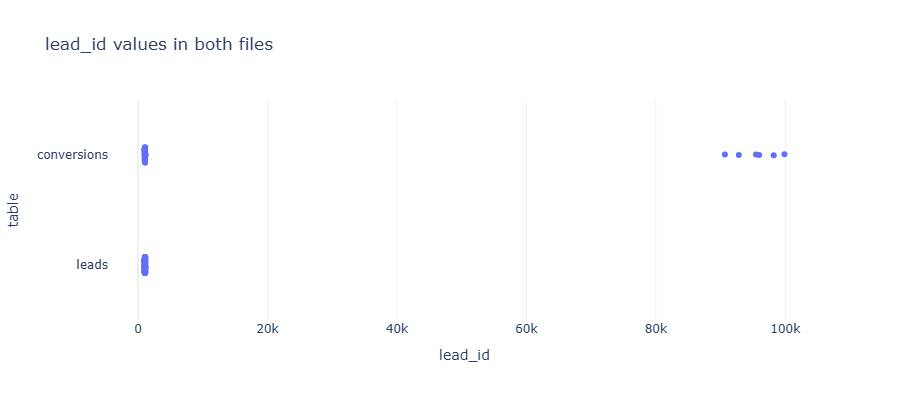

In [29]:
ids = pd.concat(
    [
        pd.DataFrame({"lead_id": leads_unique["lead_id"], "table": "leads"}),
        pd.DataFrame({"lead_id": conv["lead_id"], "table": "conversions"}),
    ],
    ignore_index=True,
).dropna()

fig = px.strip(ids, x="lead_id", y="table", title="lead_id values in both files")
fig.show()

**Finding:** 41 of the 50 distinct conversions link to a lead. 3 have no `lead_id`, and 6 point to ids between
90,672 and 99,874, far outside the range of the leads (1001–1119). They look like ids from another system or id
range rather than typos. Together that makes 9 orphan conversions (18 %).

How often does the same `lead_id` appear in the conversions? That decides the grain of the lead-to-conversion
model.

In [30]:
(
    conv["lead_id"]
    .value_counts()
    .value_counts()
    .rename_axis("conversions per lead_id")
    .rename("lead_ids")
)

conversions per lead_id
1    47
Name: lead_ids, dtype: Int64

**Finding:** every `lead_id` occurs at most once in the conversions, so a lead has no conversion or exactly one
(1 : 0..1). The model in Task 2 can join conversions to leads without multiplying rows.

**Left for Task 2:** whether the orphans can be linked by e-mail instead, whether the time between lead and
contract supports the date assumption, and which leads are affected by the DQ issues once the files are joined.
These are modelling questions rather than properties of the raw files.

## 10. Data-quality issue register

Criticality scale:
- **High**: silently produces wrong KPIs or wrong joins if not handled.
- **Medium**: affects some records or specific breakdowns; handling needed but impact limited.
- **Low**: cosmetic, or informational for modelling.

| # | Issue | Evidence | Criticality | Handling |
|---|-------|----------|-------------|----------|
| 1 | **Orphan conversions**: `lead_id` missing or pointing to a non-existent lead | 9 of 50 distinct conversions (18 %): 3 without `lead_id`, 6 with ids `90672–99874`, far outside the lead range `1001–1119` (9) | High | Never drop them silently: keep them in the model with a match status. Whether they can be linked by e-mail instead is analysed in Task 2. A blind e-mail join is risky, because 21 addresses have several leads (7). |
| 2 | **Duplicate `lead_id` with conflicting content** | 4 ids. `region` differs in all 4, `source` in 2, `vertical` in 1; `email` and `created_at` never differ (7) | High | Leads would be double-counted and joins would multiply rows. Deduplicate to one row per `lead_id` (rule decided in Task 2) and flag the affected leads. Uniqueness test on `lead_id`. Ask the source owner about the region pattern, which suggests an upstream fan-out join. |
| 3 | **Exact duplicate conversion** | `conversion_id` 5020 appears twice (7) | High | Double-counts conversions and premium. Drop exact duplicates in staging, plus a uniqueness test on `conversion_id`. |
| 4 | **Mixed date formats** | 3 shapes (2, 6.2). The default `to_datetime` fails on 97 of 123 lead dates; `format="mixed"` raises no error but puts 14 of them on the wrong day (6.1, 6.3) | High | Parse with one explicit format per shape; values of an unknown shape fail loudly. Ask for ISO 8601 exports. |
| 5 | **Ambiguous slash dates** | 16 distinct `99/99/9999` values are ambiguous; all 17 unambiguous ones are month-first (6.2) | Medium | Parse as `%m/%d/%Y`. Documented assumption: cross-check it against the time between lead and contract in Task 2, and confirm it with the source owner. |
| 6 | **Premium with decimal comma** | 13 of 48 non-missing values; a naive cast turns them into `NaN` (8) | High | Replace `,` with `.` before casting. Test that `premium` is castable. |
| 7 | **Status values outside the documented set** | `ACTIVE` and `aktiv` next to `active` (5) | High | Directly biases "active premium" and "has an active contract". Lower-case plus mapping (`aktiv` → `active`); accepted-values test so that new variants fail the pipeline. |
| 8 | **E-mail formatting** (whitespace, capitals) | Both files; 123 raw spellings, but only 88 distinct addresses after trimming and lower-casing (2, 5) | High | E-mail is the natural customer key (Task 3); without normalisation one customer splits into several. Trim and lower-case. |
| 9 | **Negative premiums** | 2 values, both on cancelled contracts (8) | Medium | Could be refunds, reversal bookings or errors. Keep the value and flag it; excluded from "active premium" anyway. Open question. |
| 10 | **Missing premium** | 2 values, one on an **active** contract (8) | Medium | Keep as NULL, do **not** impute 0. The total active premium is understated by one contract; flag it in the customer view. |
| 11 | **Missing vertical** | 3 leads (4) | Medium | Map to `'unknown'` instead of dropping, so that lead and conversion totals still reconcile. |
| 12 | **Missing region** | 5 leads (4) | Low | Map to `'unknown'`. Not part of the required KPIs, and possibly unreliable anyway (issue 2). |
| 13 | **Same person with several leads** | 21 e-mail addresses with 2–4 leads (7) | Low (not an error) | Expected behaviour. It defines the customer grain (customer = normalised e-mail, Task 3). |
| 14 | **Same name, different e-mail domain** | 5 names, e.g. `paul.aigner@gmail.com` and `@hotmail.com` (7) | Low | Could be the same person, but the data cannot prove it. Do **not** merge (avoids false positives). Documented limitation. |
| 15 | **Time coverage and right-censoring** | Leads until 2024-10-31, conversions until 2024-11-29 (6.4) | Medium | Conversion rates of the latest lead months are understated. Compute conversion rates by **lead cohort month** (`created_at`) and mark recent months as immature. |

**Checks that passed:**
- `lead_id` in the leads and `conversion_id` have a single, clean digit shape and no missing values.
- `source` only contains the documented values, and `region` only Austrian federal states (apart from gaps).
- Every date parses with the format of its shape; there are no unknown formats.
- Every `lead_id` occurs at most once in the conversions.

## 11. From findings to the dbt pipeline

This notebook is the basis for the pipeline design. Its findings map onto three layers:
- **Raw (sources):** `leads.csv` and `conversions.csv` loaded unchanged, every column as text (as in section 1).
  Source tests only check that the files arrived with the expected columns.
- **Staging:** one model per source, `stg_leads` and `stg_conversions`. They apply the fixes of this notebook and
  nothing else: no joins, no business rules.
- **Marts:** the lead-to-conversion model and the KPI and customer views (Tasks 2 and 3).

### Staging rules and tests per column

`stg_leads`

| column | type | rule (section) | dbt test |
|---|---|---|---|
| `lead_id` | integer | cast (3) | `not_null`; `unique` (fails today: 4 duplicates, 7) |
| `email` | text | trim, lower-case (3, 5) | `not_null` |
| `vertical` | text | trim; missing → `'unknown'` (4) | `accepted_values`: auto, haushalt, leben, unknown |
| `source` | text | trim (3) | `not_null`; `accepted_values`: google, newsletter, direct |
| `created_at` | date | parse with one format per shape (6) | `not_null` (catches unknown formats) |
| `region` | text | trim; missing → `'unknown'` (4) | `accepted_values`: the 9 federal states and unknown (severity `warn`) |

`stg_conversions`

| column | type | rule (section) | dbt test |
|---|---|---|---|
| `conversion_id` | integer | cast; drop exact duplicate rows (3, 7) | `not_null`; `unique` |
| `lead_id` | integer, nullable | cast (3) | `relationships` to `stg_leads.lead_id` (severity `warn`: 9 known orphans) |
| `email` | text | trim, lower-case (3, 5) | `not_null` |
| `premium` | decimal | replace `,` with `.`, then cast (8) | `not_null` and `>= 0`, both severity `warn` (2 missing, 2 negative) |
| `signed_date` | date | parse with one format per shape (6) | `not_null` |
| `status` | text | lower-case; `aktiv` → `active` (5) | `accepted_values`: active, cancelled, pending |

**Severity.** Known issues become tests with severity `warn` plus a threshold (`error_if`). For example, the
relationships test warns about the 9 known orphans but fails the run if their number grows. Rules that protect
the KPIs directly (unique keys, accepted status values, parseable dates) fail with `error`.

**Format checks.** The shape idea from section 2 becomes a generic test: a date column may only contain known
shapes. A new export format then fails loudly in staging, instead of turning into `NULL` or a wrong date.

**Decisions left for the modelling tasks**
- Which copy of a duplicated lead wins (Task 2).
- How orphan conversions are handled, and whether they can be linked by e-mail (Task 2).
- What counts as a conversion (is `pending` one?) and what counts as a customer (Task 3).

## 12. Assumptions & open questions

**Assumptions**
- Slash dates are month-first (`%m/%d/%Y`), because all unambiguous slash dates are month-first. Task 2
  cross-checks this against the time between lead and contract.
- The e-mail address (trimmed, lower-cased) identifies a person. Different domains are treated as different people.
- `premium` is the annual net premium per contract, in EUR, without thousands separators.
- Duplicate lead rows describe the same lead event; which copy wins is decided in Task 2.
- `aktiv` is the German spelling of `active`.

**Open questions (for the business / data owners)**
1. Where do the lead ids `9xxxx` come from: another system, a test environment, an old id range? Is there a
   mapping table?
2. Why do duplicated lead rows differ in `region` every time, and sometimes in `source`? Is region looked up per
   session or per address, i.e. is there a fan-out join upstream? Which system is the source of truth for `source`
   (marketing attribution)?
3. Which system produces the `MM/DD/YYYY` dates? Can the exports be switched to ISO 8601?
4. What does a negative premium mean: a refund, a reversal booking, or an error?
5. Does a `pending` contract count as a conversion? This decides the conversion definition in Task 3.
6. Should customers be matched across e-mail domains (e.g. via name or phone), or is the e-mail address the agreed
   customer key?